## PHB 221: Geographic Trends in Heart Disease Mortality

## Introduction


In the research field, there is a strong focus on cancer as a public health concern, but we can’t forget that heart disease still remains as one of the main leading causes of deaths in the United States. According to the Centers for Disease Control and Prevention (CDC), heart disease is the leading cause of death across most racial and ethnic groups, which is responsible for about 1 in every 5 deaths.

For our project, we will analyze publicly available data from the National Center for Health Statistics (NCHS), specifically on the “NCHS - Leading Causes of Death: United States” dataset. Our main focus will be to analyze state level patterns in age adjusted death rates for heart disease over time, and see if there are significant differences across states and regions.

From this dataset, its features include year, state, number of deaths, and age adjusted death rates. We will go through two main research questions, one being an inferential analysis and the other being predictive modeling. 



## Main Question

1. Do age adjusted heart disease death rates significantly differ in different states/regions as they change over time?
2. Can past trends in age adjusted heart disease death rates be used to predict future state level rates?

## Exploratory Analysis

In [ ]:
# libraries needed

import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [14]:
# load data
data = pd.read_csv('NCHS_-_Leading_Causes_of_Death__United_States.csv')

# check data dimension, shape
shape = data.shape

print(f"Data Shape: {shape}")

# check for any missing values
missing_values = data.isnull().sum()
print(f"Missing Values:\n{missing_values}")

Data Shape: (10868, 6)
Missing Values:
Year                       0
113 Cause Name             0
Cause Name                 0
State                      0
Deaths                     0
Age-adjusted Death Rate    0
dtype: int64


In [ ]:
# all different types of column outputs for Cause Name
data["Cause Name"].unique()

array(['Unintentional injuries', 'All causes', "Alzheimer's disease",
       'Stroke', 'CLRD', 'Diabetes', 'Heart disease',
       'Influenza and pneumonia', 'Suicide', 'Cancer', 'Kidney disease'],
      dtype=object)

In [4]:
# preview data
data.head()

,Year,113 Cause Name,Cause Name,State,Deaths,Age-adjusted Death Rate
0,2017,"Accidents (unintentional injuries) (V01-X59,Y8...",Unintentional injuries,United States,169936,49.4
1,2017,"Accidents (unintentional injuries) (V01-X59,Y8...",Unintentional injuries,Alabama,2703,53.8
2,2017,"Accidents (unintentional injuries) (V01-X59,Y8...",Unintentional injuries,Alaska,436,63.7
3,2017,"Accidents (unintentional injuries) (V01-X59,Y8...",Unintentional injuries,Arizona,4184,56.2
4,2017,"Accidents (unintentional injuries) (V01-X59,Y8...",Unintentional injuries,Arkansas,1625,51.8


In [ ]:
# check specifically for Cause Name Heart Disease and State United States
heart_disease_data = data[(data['Cause Name'] == 'Heart disease') & (data['State'] == 'United States')]
heart_disease_data

,Year,113 Cause Name,Cause Name,State,Deaths,Age-adjusted Death Rate
312,2017,"Diseases of heart (I00-I09,I11,I13,I20-I51)",Heart disease,United States,647457,165.0
929,2016,"Diseases of heart (I00-I09,I11,I13,I20-I51)",Heart disease,United States,635260,165.5
1501,2015,"Diseases of heart (I00-I09,I11,I13,I20-I51)",Heart disease,United States,633842,168.5
2074,2014,"Diseases of heart (I00-I09,I11,I13,I20-I51)",Heart disease,United States,614348,167.0
2648,2013,"Diseases of heart (I00-I09,I11,I13,I20-I51)",Heart disease,United States,611105,169.8
3220,2012,"Diseases of heart (I00-I09,I11,I13,I20-I51)",Heart disease,United States,599711,170.5
3793,2011,"Diseases of heart (I00-I09,I11,I13,I20-I51)",Heart disease,United States,596577,173.7
4365,2010,"Diseases of heart (I00-I09,I11,I13,I20-I51)",Heart disease,United States,597689,179.1
4953,2009,"Diseases of heart (I00-I09,I11,I13,I20-I51)",Heart disease,United States,599413,182.8
5527,2008,"Diseases of heart (I00-I09,I11,I13,I20-I51)",Heart disease,United States,616828,192.1


Between 1999 and 2017, the U.S age adjusted death rate for heart disease showed a consistent downward trend, with a decrease of 38%, meaning starting from 1999 there was about 266 deaths per 100,000, while in 2017 there was about 165 deaths per 100,000. 

This shows that, over the past couple years, there has been improvements in heart disease prevention, awareness, treatment, better management of hypertension and cholesterol, and development of emergency medical care. 

While the decline show noticeable progress within the public health field, heart disease still remains to be be one of the leading cause of death in the U.S, showcasing that there is still continued need for early more improvement in prevention and its ways in earlier detection. As seen in figure [idek], the decline is steady and consistent, but digging deeper into each state might not showcase the same results. This could be due to healthcare access, socioeconomic factors, and lifestyle. For further state level analysis, the next section will do a analysis similar to the national trend, by examining its trends given the same time periods. 

Percentage Change in Age-adjusted Death Rate from 1999 to 2020: -38.09%


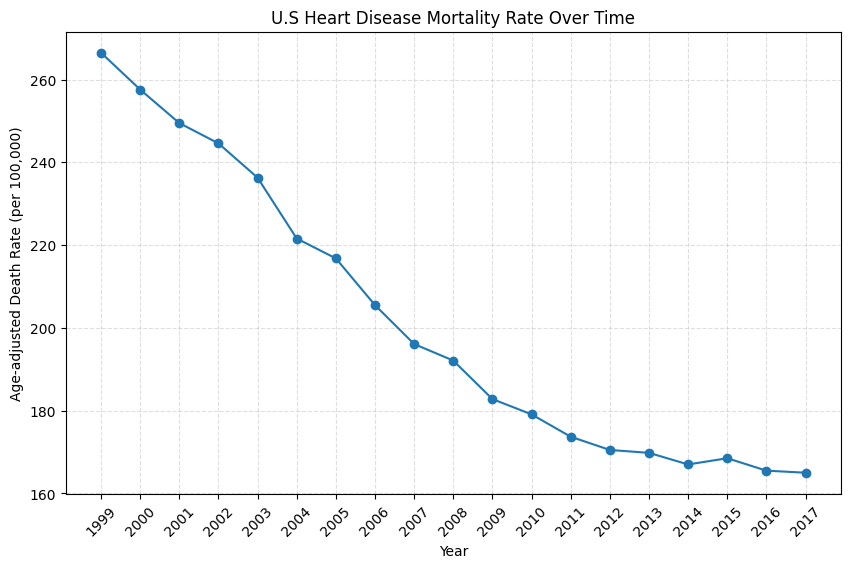

In [43]:
# sort values by year
sorted_heart_disease_data = heart_disease_data.sort_values(by = 'Year')

# create figure
plt.figure(figsize=(10,6))
plt.plot(sorted_heart_disease_data['Year'], sorted_heart_disease_data['Age-adjusted Death Rate'], marker = 'o')

# add titles and labels
plt.title("U.S Heart Disease Mortality Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Age-adjusted Death Rate (per 100,000)")

plt.xticks(sorted_heart_disease_data['Year'], rotation = 45)
plt.grid(True, linestyle = '--', alpha = 0.4)


# check percentage change from 1999 to 2020
start_date = sorted_heart_disease_data.iloc[0]['Age-adjusted Death Rate']
end_date = sorted_heart_disease_data.iloc[-1]['Age-adjusted Death Rate']
percentage_change = ((end_date - start_date) / start_date) * 100    
print(f"Percentage Change in Age-adjusted Death Rate from 1999 to 2020: {percentage_change:.2f}%")

In [ ]:
# check change by state from 1999 to 2019
heart_state = data[data['Cause Name'] == 'Heart disease'].copy()

# start from 1999 to 2019
start_year = heart_state['Year'].min()
end_year = heart_state['Year'].max()

# for each state, get start and end rates
start_rates = heart_state[heart_state['Year'] == start_year][['State', 'Age-adjusted Death Rate']]
end_rates = heart_state[heart_state['Year'] == end_year][['State', 'Age-adjusted Death Rate']]

# merge start and end rates
merged = start_rates.merge(end_rates, on='State', suffixes=('_Start', '_End'))

# compute percentage change
merged['% Change'] = ((merged['Age-adjusted Death Rate_End'] - merged['Age-adjusted Death Rate_Start']) / merged['Age-adjusted Death Rate_Start']) * 100

# sort by most most decrease
merged = merged.sort_values('% Change')
print(merged[['State', '% Change']])


                   State   % Change
4             California -44.461718
32              New York -44.070565
13              Illinois -41.490505
34          North Dakota -41.161401
7               Delaware -41.158990
9                Florida -41.138474
21         Massachusetts -41.050328
49         West Virginia -41.013825
6            Connecticut -40.703518
33        North Carolina -40.015332
30            New Jersey -40.000000
19                 Maine -39.882698
47              Virginia -38.421682
23             Minnesota -38.097713
44         United States -38.086304
10               Georgia -37.835926
38          Pennsylvania -37.522187
5               Colorado -37.493632
43                 Texas -37.356535
40        South Carolina -37.088515
17              Kentucky -36.989386
29         New Hampshire -36.621507
20              Maryland -36.535494
27              Nebraska -36.468085
25              Missouri -36.405990
2                Arizona -36.396235
39          Rhode Island -36

# next steps?
    - group states by region
    - visualize US average compared to every state
    - do the same visualization but for every region

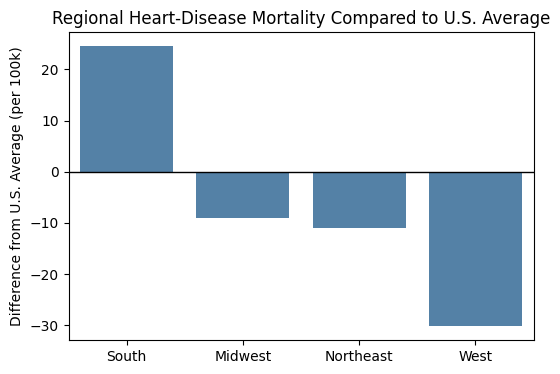

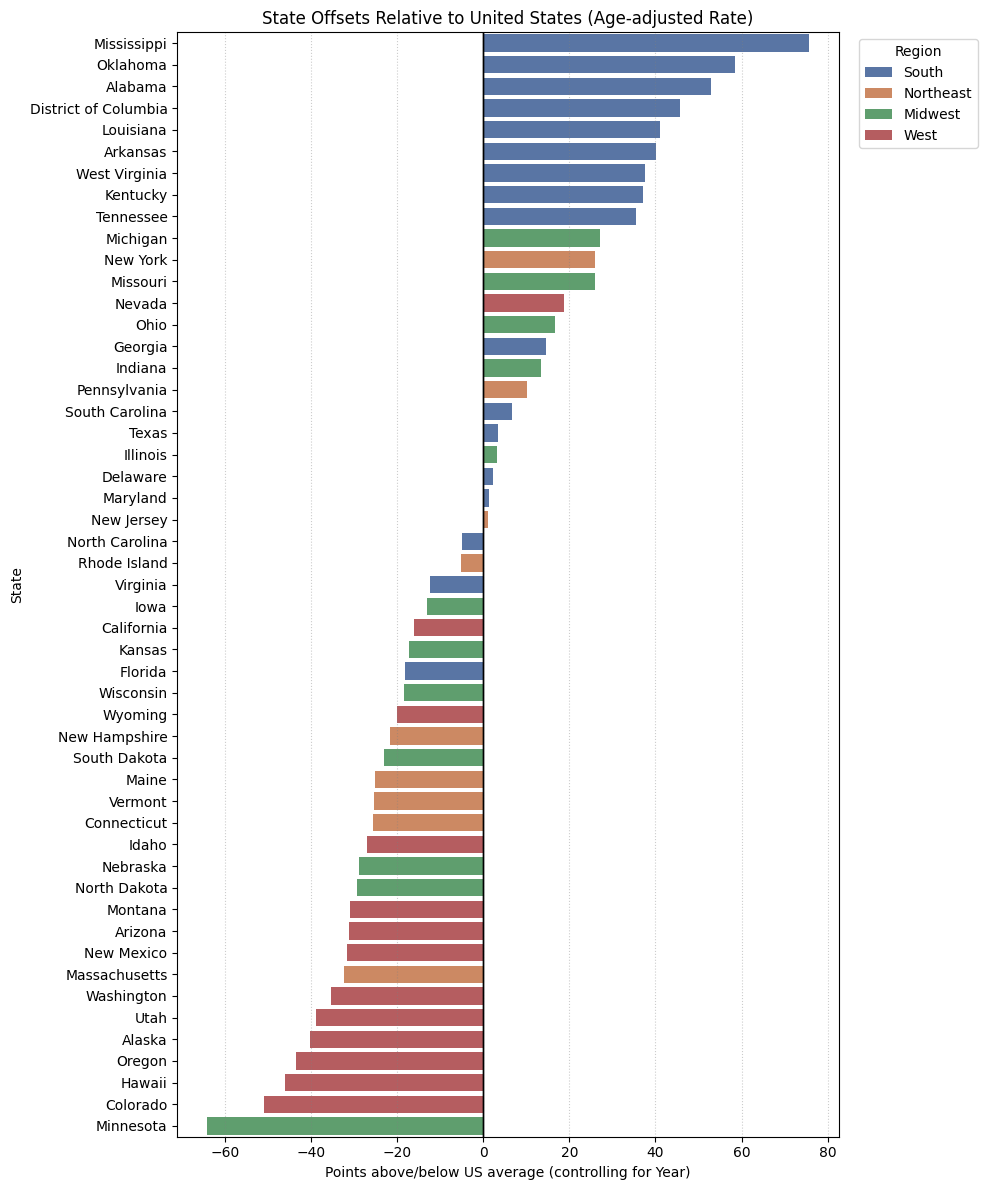

In [ ]:
# group by region

region_map = {
    # south states
    'Delaware': 'South', 'District of Columbia': 'South', 'Florida': 'South', 'Georgia': 'South',
    'Maryland': 'South', 'North Carolina': 'South', 'South Carolina': 'South', 'Virginia': 'South',
    'West Virginia': 'South', 'Alabama': 'South', 'Kentucky': 'South', 'Mississippi': 'South',
    'Tennessee': 'South', 'Arkansas': 'South', 'Louisiana': 'South', 'Oklahoma': 'South', 'Texas': 'South',

    # northeast states
    'Connecticut': 'Northeast', 'Maine': 'Northeast', 'Massachusetts': 'Northeast', 'New Hampshire': 'Northeast',
    'Rhode Island': 'Northeast', 'Vermont': 'Northeast', 'New Jersey': 'Northeast', 'New York': 'Northeast',
    'Pennsylvania': 'Northeast',

    # midwest states
    'Illinois': 'Midwest', 'Indiana': 'Midwest', 'Michigan': 'Midwest', 'Ohio': 'Midwest', 'Wisconsin': 'Midwest',
    'Iowa': 'Midwest', 'Kansas': 'Midwest', 'Minnesota': 'Midwest', 'Missouri': 'Midwest', 'Nebraska': 'Midwest',
    'North Dakota': 'Midwest', 'South Dakota': 'Midwest',

    # west states
    'Alaska': 'West', 'Arizona': 'West', 'California': 'West', 'Colorado': 'West', 'Hawaii': 'West',
    'Idaho': 'West', 'Montana': 'West', 'Nevada': 'West', 'New Mexico': 'West', 'Oregon': 'West',
    'Utah': 'West', 'Washington': 'West', 'Wyoming': 'West'
}

heart_state = heart_state[heart_state['State'] != 'United States'].copy()

us = (
    data[(data['Cause Name'] == 'Heart disease') & (data['State'] == 'United States')]
    [['Year', 'Age-adjusted Death Rate']]
    .rename(columns={'Age-adjusted Death Rate': 'Rate_US'})
)

# each state now has US rate for that year
merged = heart_state.merge(us, on='Year', how='left')

# calculate difference
merged['Effect vs US'] = merged['Age-adjusted Death Rate'] - merged['Rate_US']

# map the regions (stated above)
merged['Region'] = merged['State'].map(region_map)

# take the average effect by region
region_summary = (
    merged.groupby('Region', dropna=False)['Effect vs US']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)


plt.figure(figsize=(6, 4))
sns.barplot(data=region_summary, x='Region', y='Effect vs US', color='steelblue')
plt.axhline(0, color='black', lw=1)
plt.title('Regional Heart-Disease Mortality Compared to U.S. Average')
plt.ylabel('Difference from U.S. Average (per 100k)')
plt.xlabel('')

# state level 
state_df = (
    merged.groupby(['State','Region'], as_index=False)['Effect vs US'].mean()
)

state_df = state_df[state_df['State'] != 'United States'].copy()

y_order = state_df.sort_values('Effect vs US', ascending=False)['State']

hue_order = ['South', 'Northeast', 'Midwest', 'West']

region_palette = {
    'South':    '#4C72B0',
    'Northeast':'#DD8452',
    'Midwest':  '#55A868',
    'West':     '#C44E52'
}

plt.figure(figsize=(10,12))
sns.barplot(
    data=state_df,
    x='Effect vs US',
    y='State',
    hue='Region',
    dodge=False,
    order=y_order,
    hue_order=hue_order,
    palette=region_palette
)
plt.axvline(0, color='k', lw=1)
plt.title('State Offsets Relative to United States (Age-adjusted Rate)')
plt.xlabel('Points above/below US average (controlling for Year)')
plt.ylabel('State')
plt.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')


plt.grid(True, axis='x', linestyle=':', color='gray', alpha=0.4)
plt.axvline(0, color='black', lw=1)
plt.tight_layout()
plt.show()


## Initial Analysis

- summaries, time trends

In [ ]:
# complete later

## Next Steps

- Statistical Analysis
    - maybe ANOVA tests (differences across states and over time)

- Predictive Modeling
    - Linear regression (estimate yearly changes and predict future rates, also prob correlation between output and features)
        - will most likely use simple linear regression than multiple linear regression
    - Other models to test with? Which model has the best accuracy?
    - Could use confusion matrix to see TP, TN, FP, FN
    - for predictive modeling split dataset into 80/10/10 or use the entire dataset as train and find new dataset 2017-2025 for test
        - check its accuracy, R^2 and RMSE